# CS570 Week 8 Lab: Fraud Detection — Classification in PySpark

**Objective:** Build and compare two classification models (Logistic Regression
and Decision Tree) on a credit-card fraud dataset. Evaluate using the metrics
from today's lecture: Precision, Recall, F1, AUC, and the confusion matrix.

**What's provided:** Data loading, exploratory visualizations, and evaluation code.

**What you write:** Feature engineering, VectorAssembler, and the two models.

---

## Step 0: Setup

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

import matplotlib.pyplot as plt
import numpy as np

spark = SparkSession.builder \
    .appName("CS570_Week8_FraudClassification") \
    .getOrCreate()

print("Spark session ready!")

Spark session ready!


## Step 1: Load the Fraud Dataset

This is a synthetic credit-card transaction dataset with ~1,000 rows.
Each row is one transaction. The target column is `is_fraud` (0 = legit, 1 = fraud).

In [6]:
df = spark.read.csv("fraud_transactions.csv", header=True, inferSchema=True)

print(f"Total transactions: {df.count():,}")
df.printSchema()
df.show(5)

Total transactions: 1,000
root
 |-- transaction_id: integer (nullable = true)
 |-- amount: double (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_online: integer (nullable = true)
 |-- distance_from_home: double (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- is_fraud: integer (nullable = true)

+--------------+------+----+-----------+---------+------------------+-----------------+--------+
|transaction_id|amount|hour|day_of_week|is_online|distance_from_home|merchant_category|is_fraud|
+--------------+------+----+-----------+---------+------------------+-----------------+--------+
|        100000| 21.78|  13|          5|        0|               8.8|       restaurant|       0|
|        100001| 64.36|   9|          3|        0|               8.5|         clothing|       0|
|        100002| 26.74|  11|          5|        0|               5.2|       restaurant|       0|
|        100003| 20.41|   9|          

In [7]:
# Quick summary statistics
df.describe().show()

+-------+-----------------+-----------------+-----------------+------------------+-----------------+------------------+-----------------+-------------------+
|summary|   transaction_id|           amount|             hour|       day_of_week|        is_online|distance_from_home|merchant_category|           is_fraud|
+-------+-----------------+-----------------+-----------------+------------------+-----------------+------------------+-----------------+-------------------+
|  count|             1000|             1000|             1000|              1000|             1000|              1000|             1000|               1000|
|   mean|         100499.5|63.12994000000002|           11.706|             3.014|             0.31| 18.01000000000001|             NULL|                0.1|
| stddev|288.8194360957494|99.08304098991007|4.578703804411088|1.9686745997446307|0.462724663395106| 42.46624261412543|             NULL|0.30015011259383184|
|    min|           100000|             5.16|       

## Step 2: Explore & Visualize

Run all cells below to understand the data before building your model.
Pay attention to what separates fraud from legit transactions — this will
guide your feature engineering in Step 3.

### 2a — Class Balance

Fraud rate: 10.0%


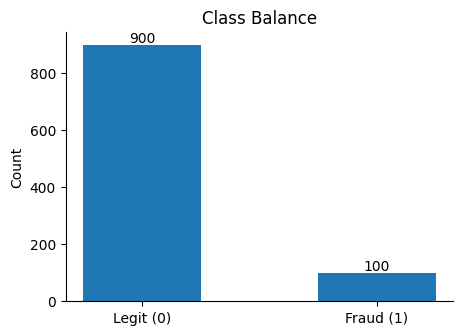

In [8]:
# Class balance
class_counts = df.groupBy("is_fraud").count().orderBy("is_fraud").toPandas()

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(class_counts["is_fraud"].astype(str), class_counts["count"], width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"])
ax.set_ylabel("Count")
ax.set_title("Class Balance")
for bar, val in zip(bars, class_counts["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(val), ha="center")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fraud_pct = 100 * class_counts[class_counts["is_fraud"]==1]["count"].values[0] / class_counts["count"].sum()
print(f"Fraud rate: {fraud_pct:.1f}%")

✋ **Prediction Point #1:** Is this dataset balanced or imbalanced?
What problems might this cause for a classifier?

*Your answer:*

### 2b — Transaction Amount by Class

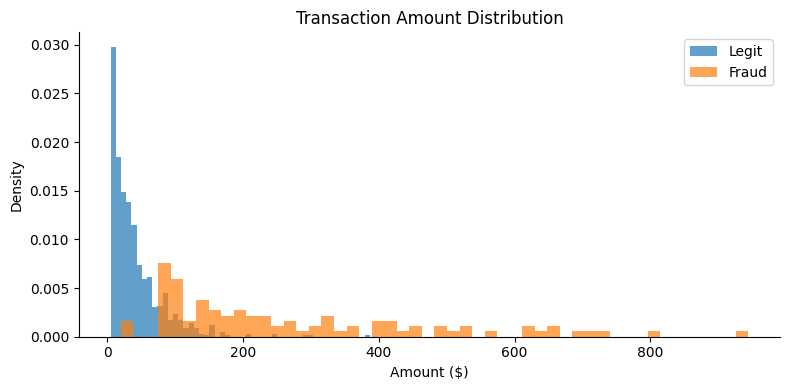

Legit transactions:
+-------+------------------+
|summary|            amount|
+-------+------------------+
|  count|               900|
|   mean| 40.60161111111113|
| stddev|38.735491972295954|
|    min|              5.16|
|    max|             387.6|
+-------+------------------+

Fraud transactions:
+-------+------------------+
|summary|            amount|
+-------+------------------+
|  count|               100|
|   mean|265.88489999999996|
| stddev| 198.2500990076816|
|    min|             19.98|
|    max|            943.81|
+-------+------------------+



In [9]:
# Amount distribution: fraud vs legit
pdf = df.select("amount", "is_fraud").toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pdf[pdf["is_fraud"]==0]["amount"], bins=50, alpha=0.7, label="Legit", density=True)
ax.hist(pdf[pdf["is_fraud"]==1]["amount"], bins=50, alpha=0.7, label="Fraud", density=True)
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Density")
ax.set_title("Transaction Amount Distribution")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Summary stats
print("Legit transactions:")
df.filter(col("is_fraud")==0).select("amount").describe().show()
print("Fraud transactions:")
df.filter(col("is_fraud")==1).select("amount").describe().show()

### 2c — Fraud Rate by Hour of Day

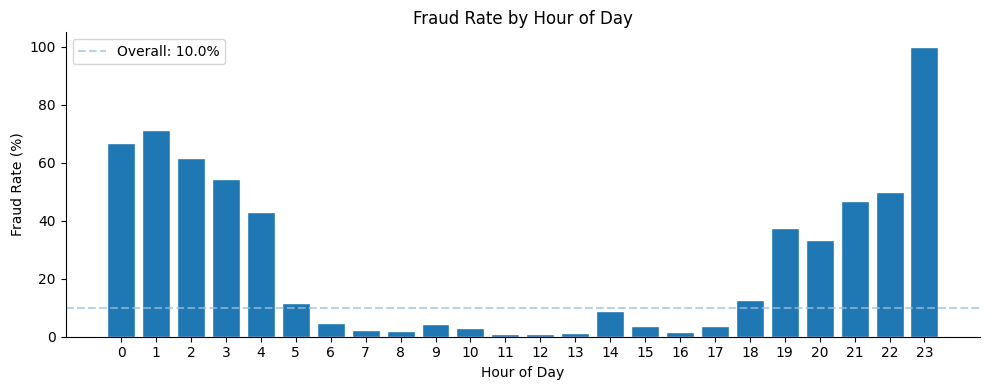

In [10]:
# Fraud rate by hour
hourly = df.groupBy("hour").agg(
    count("*").alias("total"),
    sum(col("is_fraud")).alias("fraud_count")
).withColumn("fraud_rate", round(col("fraud_count") / col("total") * 100, 1)) \
 .orderBy("hour").toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly["hour"], hourly["fraud_rate"], edgecolor="white")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Hour of Day")
ax.set_xticks(range(24))
ax.axhline(y=fraud_pct, color="#9BBFDC", linestyle="--", alpha=0.7, label=f"Overall: {fraud_pct:.1f}%")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 2d — Fraud Rate by Merchant Category

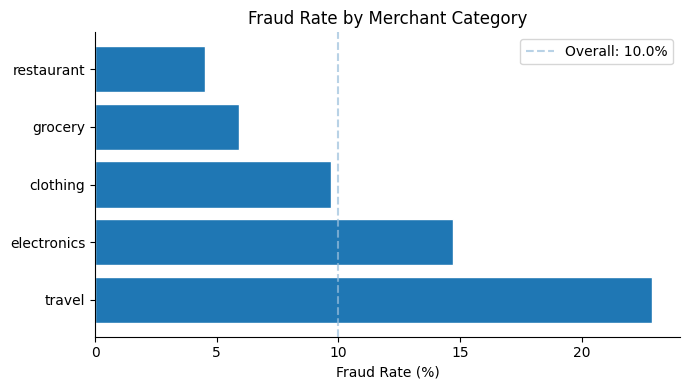

In [11]:
# Fraud rate by category
cat_stats = df.groupBy("merchant_category").agg(
    count("*").alias("total"),
    sum(col("is_fraud")).alias("fraud_count")
).withColumn("fraud_rate", round(col("fraud_count") / col("total") * 100, 1)) \
 .orderBy(col("fraud_rate").desc()).toPandas()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(cat_stats["merchant_category"], cat_stats["fraud_rate"], edgecolor="white")
ax.set_xlabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Merchant Category")
ax.axvline(x=fraud_pct, color="#9BBFDC", linestyle="--", alpha=0.7, label=f"Overall: {fraud_pct:.1f}%")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 2e — Distance from Home & Online vs In-Store

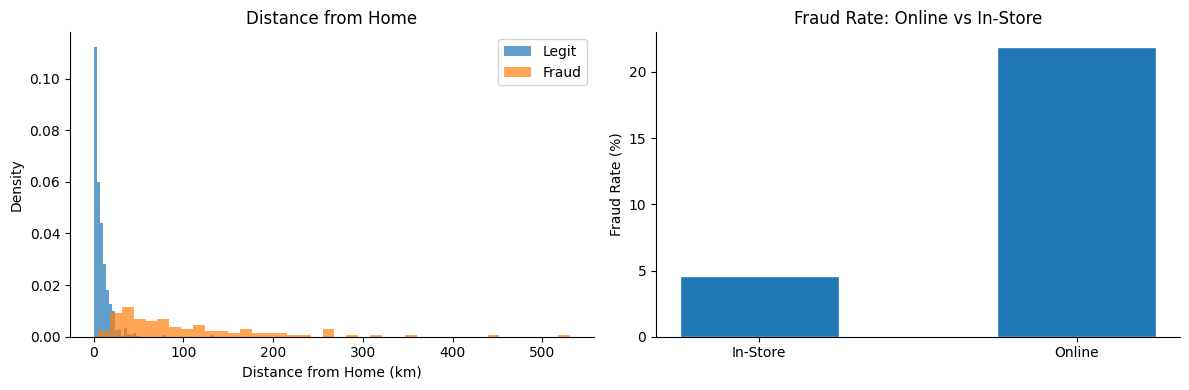

In [12]:
# Distance from home + online/in-store
pdf2 = df.select("distance_from_home", "is_fraud", "is_online").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distance histogram
axes[0].hist(pdf2[pdf2["is_fraud"]==0]["distance_from_home"], bins=40, alpha=0.7, label="Legit", density=True)
axes[0].hist(pdf2[pdf2["is_fraud"]==1]["distance_from_home"], bins=40, alpha=0.7, label="Fraud", density=True)
axes[0].set_xlabel("Distance from Home (km)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distance from Home")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right: online fraud rate
online_stats = df.groupBy("is_online").agg(
    count("*").alias("total"),
    sum(col("is_fraud")).alias("fraud_count")
).withColumn("fraud_rate", round(col("fraud_count") / col("total") * 100, 1)) \
 .orderBy("is_online").toPandas()
axes[1].bar(["In-Store", "Online"], online_stats["fraud_rate"], edgecolor="white", width=0.5)
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_title("Fraud Rate: Online vs In-Store")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

📌 **Discussion:** Look at all the charts above. Which features seem
most useful for detecting fraud? Keep these in mind for Step 3.

## Step 3: Feature Engineering ✍️

**Your turn.** Create features that will help the model distinguish fraud from legit.

You already have raw numeric columns: `amount`, `hour`, `is_online`, `distance_from_home`, `day_of_week`.

But you can also **derive** new features. Consider:

| Idea | Hint |
|------|------|
| Is it nighttime? | create an is_night for the time period with a significant higher fraud rate |
| Is the amount unusually high? | What was the overall median amount from Step 2? |
| Encode merchant category | Use `StringIndexer` to turn category names into numbers |

**Minimum:** use at least 4 features. **Challenge:** create 6+ including at least one derived feature.

Write your feature engineering code below:

In [ ]:
# ──────────────────────────────────────────
# YOUR CODE: Feature engineering
# ──────────────────────────────────────────

# Example: create an is_night feature
# df = df.withColumn("is_night", when( ... , 1).otherwise(0))

# Example: encode merchant_category as a number
# indexer = StringIndexer(inputCol="merchant_category", outputCol="category_index")
# df = indexer.fit(df).transform(df)

# YOUR CODE HERE



In [ ]:
df = df.withColumn("is_night", when((col("hour") >= 18) & (col("hour") <= 4), 1).otherwise(0))
# Median from EDA was ~$50
df = df.withColumn("high_amount", when(col("amount") > 200, 1).otherwise(0))
indexer = StringIndexer(inputCol="merchant_category", outputCol="category_index")
df = indexer.fit(df).transform(df)


In [15]:
df.show(5)

+--------------+------+----+-----------+---------+------------------+-----------------+--------+--------+-----------+--------------+
|transaction_id|amount|hour|day_of_week|is_online|distance_from_home|merchant_category|is_fraud|is_night|high_amount|category_index|
+--------------+------+----+-----------+---------+------------------+-----------------+--------+--------+-----------+--------------+
|        100000| 21.78|  13|          5|        0|               8.8|       restaurant|       0|       0|          0|           1.0|
|        100001| 64.36|   9|          3|        0|               8.5|         clothing|       0|       0|          0|           3.0|
|        100002| 26.74|  11|          5|        0|               5.2|       restaurant|       0|       0|          0|           1.0|
|        100003| 20.41|   9|          4|        0|              20.7|       restaurant|       0|       0|          0|           1.0|
|        100004|109.89|   7|          5|        0|               3.1|

## Step 4: VectorAssembler + Train/Test Split ✍️

Combine your chosen features into a single vector column, then split 80/20.

**Hints:**
```python
feature_cols = ["amount", "hour", ...]   # list your feature column names

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
model_df = assembler.transform(df).select("features", "is_fraud")

train, test = model_df.randomSplit([0.8, 0.2], seed=42)
```

In [ ]:
# ──────────────────────────────────────────
# YOUR CODE: VectorAssembler + split
# ──────────────────────────────────────────

feature_cols = [  # <-- fill in your feature column names

]

# YOUR CODE HERE

# Print counts to verify
# print(f"Train: {train.count():,}  |  Test: {test.count():,}")


In [16]:
feature_cols = ["amount", "hour", "is_online", "distance_from_home",
                "is_night", "high_amount", "category_index"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
model_df = assembler.transform(df).select("features", "is_fraud")

train, test = model_df.randomSplit([0.8, 0.2], seed=42)
# train ≈ 800 rows, test ≈ 200 rows


## Step 5: Logistic Regression ✍️

Train a logistic regression model on your training set.

**Hints:**
```python
lr = LogisticRegression(featuresCol="features", labelCol="is_fraud", maxIter=20)
lr_model = lr.fit(train)
lr_predictions = lr_model.transform(test)
```

In [ ]:
# ──────────────────────────────────────────
# YOUR CODE: Train Logistic Regression
# ──────────────────────────────────────────

# YOUR CODE HERE

# Peek at predictions
# lr_predictions.select("is_fraud", "prediction", "probability").show(5, truncate=False)


In [17]:
lr = LogisticRegression(featuresCol="features", labelCol="is_fraud", maxIter=20)
lr_model = lr.fit(train)
lr_predictions = lr_model.transform(test)


## Step 6: Decision Tree ✍️

Train a decision tree classifier on the same training set.

**Hints:**
```python
dt = DecisionTreeClassifier(featuresCol="features", labelCol="is_fraud", maxDepth=5)
dt_model = dt.fit(train)
dt_predictions = dt_model.transform(test)
```

In [ ]:
# ──────────────────────────────────────────
# YOUR CODE: Train Decision Tree
# ──────────────────────────────────────────

# YOUR CODE HERE

# Peek at predictions
# dt_predictions.select("is_fraud", "prediction", "probability").show(5, truncate=False)


In [18]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="is_fraud", maxDepth=5)
dt_model = dt.fit(train)
dt_predictions = dt_model.transform(test)


## Step 7: Evaluate & Compare Both Models

Run the cells below to compute all the metrics from today's lecture.

**⚠️ Make sure** your variables are named `lr_predictions` and `dt_predictions`
(from Steps 5 and 6) before running this section.

In [19]:
def evaluate_model(predictions, label_col="is_fraud"):
    """Compute AUC, accuracy, precision, recall, F1 for a predictions DataFrame."""
    
    # AUC (threshold-free)
    bin_eval = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction")
    auc = bin_eval.evaluate(predictions)

    # Threshold-dependent metrics
    mc_eval = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction")
    accuracy  = mc_eval.evaluate(predictions, {mc_eval.metricName: "accuracy"})
    precision = mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedPrecision"})
    recall    = mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedRecall"})
    f1        = mc_eval.evaluate(predictions, {mc_eval.metricName: "f1"})

    return {"AUC": auc, "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1": f1}

lr_metrics = evaluate_model(lr_predictions)
dt_metrics = evaluate_model(dt_predictions)

# Print side by side
print(f"{'Metric':<12} {'LogReg':>10} {'DecTree':>10}")
print("─" * 34)
for metric in ["AUC", "Accuracy", "Precision", "Recall", "F1"]:
    print(f"{metric:<12} {lr_metrics[metric]:>10.4f} {dt_metrics[metric]:>10.4f}")

Metric           LogReg    DecTree
──────────────────────────────────
AUC              0.9396     0.9101
Accuracy         0.9753     0.9815
Precision        0.9760     0.9812
Recall           0.9753     0.9815
F1               0.9737     0.9812


**Record your results:**

| Metric    | Logistic Regression | Decision Tree |
|-----------|--------------------|--------------|
| AUC       |     0.9396               |   0.9101            |
| Accuracy  |      0.9753                   |    0.9815          |
| Precision |        0.9760            |      0.9812        |
| Recall    |           0.9753          |     0.9815         |
| F1        |          0.9737          |        0.9812      |

### Confusion Matrix

The confusion matrix shows TP, FP, TN, FN — the four outcomes from today's lecture.

Logistic Regression:


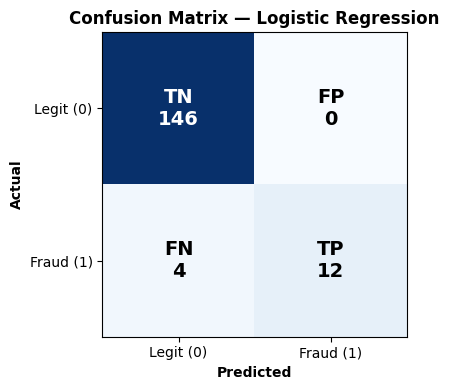

  TP=12  FP=0  TN=146  FN=4
  Precision = TP/(TP+FP) = 12/12 = 1.000
  Recall    = TP/(TP+FN) = 12/16 = 0.750

Decision Tree:


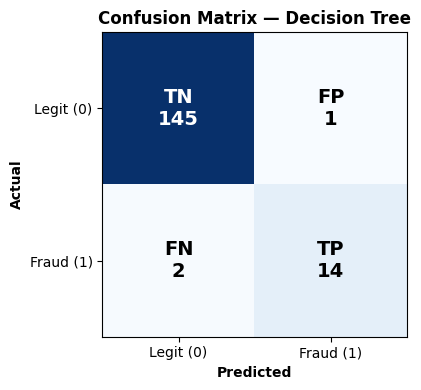

  TP=14  FP=1  TN=145  FN=2
  Precision = TP/(TP+FP) = 14/15 = 0.933
  Recall    = TP/(TP+FN) = 14/16 = 0.875


In [20]:
def plot_confusion_matrix(predictions, title, label_col="is_fraud"):
    """Compute and plot a confusion matrix from Spark predictions."""
    
    cm_df = predictions.groupBy(label_col, "prediction").count().toPandas()

    # Build 2x2 matrix
    cm = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        actual = int(row[label_col])
        pred   = int(row["prediction"])
        cm[actual][pred] = int(row["count"])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")

    # Labels
    labels = ["Legit (0)", "Fraud (1)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual", fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # Annotate cells
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i][j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cell_labels[i][j]}\n{cm[i][j]}",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color=color)

    plt.tight_layout()
    plt.show()

    # Print derived metrics
    tp, fp, tn, fn = cm[1][1], cm[0][1], cm[0][0], cm[1][0]
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    if tp + fp > 0:
        print(f"  Precision = TP/(TP+FP) = {tp}/{tp+fp} = {tp/(tp+fp):.3f}")
    if tp + fn > 0:
        print(f"  Recall    = TP/(TP+FN) = {tp}/{tp+fn} = {tp/(tp+fn):.3f}")

print("Logistic Regression:")
plot_confusion_matrix(lr_predictions, "Confusion Matrix — Logistic Regression")
print("\nDecision Tree:")
plot_confusion_matrix(dt_predictions, "Confusion Matrix — Decision Tree")

✋ **Prediction Point #2:** Look at the FN counts (missed fraud).
Which model catches more fraud? Which model has fewer false alarms?

*Your answer:*

## Step 8: Inspect the Models

What did each model learn? Let's look inside.

### 8a — Logistic Regression Coefficients

Each coefficient tells you how much that feature pushes the prediction
toward fraud (positive) or away from fraud (negative).

In [21]:
# Logistic regression coefficients
lr_coefficients = list(zip(feature_cols, lr_model.coefficients))
lr_coefficients.sort(key=lambda x: abs(x[1]), reverse=True)

print("Logistic Regression Coefficients:")
print("─" * 40)
for name, coef in lr_coefficients:
    direction = "→ fraud" if coef > 0 else "→ legit"
    print(f"  {name:<25} {coef:+.4f}  {direction}")
print(f"\n  Intercept: {lr_model.intercept:.4f}")

# Bar chart
names = [c[0] for c in lr_coefficients]
coefs = [c[1] for c in lr_coefficients]
colors = ["#E57373" if c > 0 else "#00416B" for c in coefs]

fig, ax = plt.subplots(figsize=(8, max(3, len(names) * 0.5)))
ax.barh(names, coefs, color=colors, edgecolor="white")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient")
ax.set_title("Logistic Regression — Feature Coefficients")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

PySparkTypeError: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float64.

### 8b — Decision Tree Rules

The decision tree is a series of if/then questions — the same idea as
the dog classifier from last week, but learned from data.

In [ ]:
# Decision tree rules
print("Decision Tree Rules:")
print("═" * 60)
print(dt_model.toDebugString)

# Feature importances
dt_importances = list(zip(feature_cols, dt_model.featureImportances))
dt_importances.sort(key=lambda x: x[1], reverse=True)

print("\nFeature Importances:")
print("─" * 40)
for name, imp in dt_importances:
    bar = "█" * int(imp * 40)
    print(f"  {name:<25} {imp:.3f}  {bar}")

✋ **Prediction Point #3:** Look at the decision tree rules.
What is the first question the tree asks? Does that match
what you saw in the EDA charts?

*Your answer:*

## Step 9: ROC Curve Visualization

The ROC curve plots TPR vs FPR at every threshold — exactly what we
drew on the whiteboard. The closer to the top-left corner, the better.

In [ ]:
def extract_roc_data(predictions, label_col="is_fraud"):
    """Extract probabilities and labels, compute ROC points."""
    # Get P(fraud) from the probability vector (index 1)
    extract_prob = udf(lambda v: float(v[1]), DoubleType())
    pdf = predictions.select(
        col(label_col).alias("label"),
        extract_prob(col("probability")).alias("prob")
    ).toPandas()

    labels = pdf["label"].values
    probs  = pdf["prob"].values

    # Sweep thresholds
    thresholds = np.linspace(0, 1, 200)
    tpr_list, fpr_list = [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (labels == 1)).sum()
        fp = ((preds == 1) & (labels == 0)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        tn = ((preds == 0) & (labels == 0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(fpr_list), np.array(tpr_list)

lr_fpr, lr_tpr = extract_roc_data(lr_predictions)
dt_fpr, dt_tpr = extract_roc_data(dt_predictions)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(lr_fpr, lr_tpr, color="#00416B", lw=2,
        label=f"Logistic Regression (AUC={lr_metrics['AUC']:.3f})")
ax.plot(dt_fpr, dt_tpr, color="#C4A052", lw=2,
        label=f"Decision Tree (AUC={dt_metrics['AUC']:.3f})")
ax.plot([0, 1], [0, 1], "--", color="#CCCCCC", label="Random (AUC=0.5)")

ax.set_xlabel("FPR (False Positive Rate)", fontsize=12)
ax.set_ylabel("TPR (True Positive Rate = Recall)", fontsize=12)
ax.set_title("ROC Curve — Model Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Step 10: Reflection Questions

Answer in your own words.

### Q1
Which model has better AUC? Which has better recall for fraud?
For a fraud detection system, which metric matters more — and why?

*Your answer:*

### Q2
Look at the logistic regression coefficients (Step 8a).
Which feature is the strongest predictor of fraud? Does this make real-world sense?

*Your answer:*

### Q3
Look at the decision tree rules (Step 8b).
Write out the first 2-3 rules in plain English (e.g., "If distance > 50 km AND ...").
Do they match what you saw in the EDA charts?

*Your answer:*

### Q4
This dataset has ~10% fraud. What would happen to your metrics if fraud
were only 1% of the data? Which metric would be most misleading?
(Hint: think about what "accuracy" would look like.)

*Your answer:*

---

## Submission

Submit this completed notebook (with all outputs visible) to Canvas.

**Checklist:**
- [ ] All code cells executed with outputs showing
- [ ] Feature engineering code written (Step 3)
- [ ] VectorAssembler + split code written (Step 4)
- [ ] Both models trained (Steps 5-6)
- [ ] Results table filled in (Step 7)
- [ ] All reflection questions answered (Step 10)